In [9]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import scipy
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
import lmfit
import ray
import os

from bio_optics.water import absorption, attenuation, backscattering, scattering, lee
from bio_optics.atmosphere import downwelling_irradiance
from bio_optics.models import hereon, model
from bio_optics.helper import resampling, utils, owt, indices, plotting
from bio_optics.water import fluorescence

In [2]:
# Define wavelength range and sampling rate
wavelengths=np.arange(400,900, 1)

In [27]:
# Select iop-model setup!

AlgaeGroupType = 'Summer' # 'Standardv2': HEREON, 'Standardv3': 'Standard', NSSummerBloomsv3': 'Summer'


# global inputs that don't change with fit params
a_md_spec_res = absorption.a_md_spec(wavelengths=wavelengths)
a_bd_spec_res = absorption.a_bd_spec(wavelengths=wavelengths)
a_w_res = resampling.resample_a_w(wavelengths=wavelengths)
if AlgaeGroupType == 'HEREON':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
if AlgaeGroupType == 'Standard':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
if AlgaeGroupType == 'Summer':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
b_bw_res = backscattering.b_bw(wavelengths=wavelengths, fresh=False)

da_W_div_dT_res = resampling.resample_da_W_div_dT(wavelengths=wavelengths)
h_C_res = fluorescence.h_C_double(wavelengths=wavelengths, W=0.75)
h_C_phycocyanin_res = fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=644)
h_C_phycoerythrin_res =fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=573)
omega_d_lambda_0_res = attenuation.omega_d_lambda_0()

E_0_res = resampling.resample_E_0(wavelengths=wavelengths)
a_oz_res = resampling.resample_a_oz(wavelengths=wavelengths)
a_ox_res = resampling.resample_a_ox(wavelengths=wavelengths)
a_wv_res = resampling.resample_a_wv(wavelengths=wavelengths)
n2_res = resampling.resample_n(wavelengths=wavelengths)

E_dd_res = downwelling_irradiance.E_dd(wavelengths=wavelengths)
E_dsa_res = downwelling_irradiance.E_dsa(wavelengths=wavelengths)
E_dsr_res = downwelling_irradiance.E_dsr(wavelengths=wavelengths)
E_d_res = E_dd_res + E_dsa_res + E_dsr_res

In [17]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=True)
    params.add('C_ism', value=0, min=0, max=100, vary=True)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.0058, vary=False)  # Diatoms
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green
    params.add('b_ratio_C_2', value=0.0042, vary=False)  # cryptophyte
    params.add('b_ratio_C_3', value=0.0082, vary=False)  # cyano blue
    params.add('b_ratio_C_4', value=0.001, vary=False)  # cyano red
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    else:
        params.add('b_ratio_C_5', value=0.0129, vary=False)  # coccolithophores , Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.0109, vary=False)  # case-1 , Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=True)  # max=0.0756
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=True)  # max=0.0756
    # params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=True)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.0185, min=0.005, max=0.032, vary=True) # test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=True, vary=False)
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params

In [31]:
## read parameters from inversion results
## CODE with parallelisation here: bio_optics/processors/simulations_Hyperspectral_perOWT_PACEv3.py
OWTList = ['1', '2', '3a', '3b', '4a', '4b', '5a', '5b', '6', '7']

outpath = "E:\Documents\projects\EnsAD\data\PACE_NN_training\TrainingData_PACE_v3_comb_fullSimulation\\"
path = "E:\Documents\projects\EnsAD\data\PACE_NN_training\TrainingData_PACE_v3_comb\\"
fnames_ = os.listdir(path)
fnames = [fn for fn in fnames_ if fn.startswith('iop_')]
origFnames = [fn for fn in fnames_ if fn.startswith('orig_')]
invFnames = [fn for fn in fnames_ if fn.startswith('inv_')]

OWT_ = '3a'
fnames =  [fn for fn in fnames if 'OWT'+OWT_ in fn]
origFnames =  [fn for fn in origFnames if 'OWT'+OWT_ in fn]
invFnames =  [fn for fn in invFnames if 'OWT'+OWT_ in fn]

## todo: can I use the parallelisation here also?

for fname in fnames[:1]:
    paramDF = pd.read_csv(path + fname, header=0, sep='\t')
    typeL = np.unique(paramDF.viop)
    for t in typeL:
        ID = np.array(paramDF.viop.values == t)
        print(t, np.sum(ID))
       
    # params = set_parameters_byDict(paramDict, params)
    ID = np.array(paramDF.viop.values == AlgaeGroupType)
    print(np.sum(ID))

    paramDF = paramDF.loc[ID,:]

    paramList = []
    for v in paramDF.columns.values:
        if len(np.unique(paramDF[v]))>1 and v!='C_phy':
            paramList.append(v)
    
    params = set_default_parameters(AlgaeGroupType)
    
    for i in np.arange(paramDF.shape[0]):
        for p in paramList:
            # Change parameters object accordingly.
            params.add(p, value= paramDF[p].values[i])
        
        if i == 0:
            R_rs_sim = hereon.forward(parameters=params, 
                                      wavelengths=wavelengths, 
                                      a_md_spec_res = a_md_spec_res,
                                      a_bd_spec_res = a_bd_spec_res,
                                      a_w_res = a_w_res,
                                      a_i_spec_res = a_i_spec_res,
                                      b_bw_res = b_bw_res, 
                                      b_i_spec_res = b_i_spec_res,
                                      h_C_res = h_C_res,
                                      h_C_phycocyanin_res = h_C_phycocyanin_res,
                                      h_C_phycoerythrin_res = h_C_phycoerythrin_res,
                                      da_W_div_dT_res = da_W_div_dT_res,
                                      E_0_res = E_0_res,
                                      a_oz_res = a_oz_res,
                                      a_ox_res = a_ox_res,
                                      a_wv_res = a_wv_res,
                                      E_dd_res = E_dd_res,
                                      E_dsa_res = E_dsa_res,
                                      E_dsr_res = E_dsr_res,
                                      E_d_res = E_d_res,
                                      n2_res = n2_res,
                                      Ls_Ed=[])
        else:
            R_rs_sim = np.vstack((R_rs_sim, hereon.forward(parameters=params, 
                                                           wavelengths=wavelengths, 
                                                           a_md_spec_res = a_md_spec_res,
                                                           a_bd_spec_res = a_bd_spec_res,
                                                           a_w_res = a_w_res,
                                                           a_i_spec_res = a_i_spec_res,
                                                           b_bw_res = b_bw_res, 
                                                           b_i_spec_res = b_i_spec_res,
                                                           h_C_res = h_C_res,
                                                           h_C_phycocyanin_res = h_C_phycocyanin_res,
                                                           h_C_phycoerythrin_res = h_C_phycoerythrin_res,
                                                           da_W_div_dT_res = da_W_div_dT_res,
                                                           E_0_res = E_0_res,
                                                           a_oz_res = a_oz_res,
                                                           a_ox_res = a_ox_res,
                                                           a_wv_res = a_wv_res,
                                                           E_dd_res = E_dd_res,
                                                           E_dsa_res = E_dsa_res,
                                                           E_dsr_res = E_dsr_res,
                                                           E_d_res = E_d_res,
                                                           n2_res = n2_res,
                                                           Ls_Ed=[])
                                            ))
            
    R_rs_sim = pd.DataFrame(R_rs_sim, columns=wavelengths.astype(str)) 
    R_rs_sim.to_csv(outpath + "Rrs_"+AlgaeGroupType+"_simulation_" + fname, header=True, sep='\t', index=False)

In [35]:
orig.columns.values

array(['Unnamed: 0', 'idx', 'idy', 'lon', 'lat', 'OWT', 'l2_flags', 'avw',
       '346', '348', '351', '353', '356', '358', '361', '363', '366',
       '368', '371', '373', '375', '378', '380', '383', '385', '388',
       '390', '393', '395', '398', '400', '403', '405', '408', '410',
       '413', '415', '418', '420', '422', '425', '427', '430', '432',
       '435', '437', '440', '442', '445', '447', '450', '452', '455',
       '457', '460', '462', '465', '467', '470', '472', '475', '477',
       '480', '482', '485', '487', '490', '492', '495', '497', '500',
       '502', '505', '507', '510', '512', '515', '517', '520', '522',
       '525', '527', '530', '532', '535', '537', '540', '542', '545',
       '547', '550', '553', '555', '558', '560', '563', '565', '568',
       '570', '573', '575', '578', '580', '583', '586', '588', '613',
       '615', '618', '620', '623', '625', '627', '630', '632', '635',
       '637', '640', '641', '642', '643', '645', '646', '647', '648',
       '650', '

## Plot / Check spectral examples
Simulations per IOP set (Summer, Standard, HEREON)  
per OWT  
Original spectra and inversion spectra (with reduced number of bands) have to be filtered to the right IOP set.

In [42]:
OWTList = ['1', '2', '3a', '3b', '4a', '4b', '5a', '5b', '6', '7']
AlgaeGroupType = 'HEREON'

outpath = "E:\Documents\projects\EnsAD\data\PACE_NN_training\TrainingData_PACE_v3_comb_fullSimulation\\"
fullFnames = os.listdir(outpath)
fullFnames = [fn for fn in fullFnames if AlgaeGroupType in fn]


path = "E:\Documents\projects\EnsAD\data\PACE_NN_training\TrainingData_PACE_v3_comb\\"
fnames_ = os.listdir(path)
fnames = [fn for fn in fnames_ if fn.startswith('iop_')]
origFnames = [fn for fn in fnames_ if fn.startswith('orig_')]
invFnames = [fn for fn in fnames_ if fn.startswith('inv_')]

OWT_ = '1'

simFnames = [fn for fn in fullFnames if 'OWT'+OWT_ in fn]
if len(simFnames)>0:
    print('sim exists for OWT', OWT_, 'IOPset', AlgaeGroupType) 
    sim = pd.read_csv(outpath + simFnames[0], header=0, sep='\t')
    wv_sim_str = sim.columns.values
    wv_sim = [float(a) for a in wv_sim_str]

fnames =  [fn for fn in fnames if 'OWT'+OWT_ in fn]
origFnames =  [fn for fn in origFnames if 'OWT'+OWT_ in fn]
invFnames =  [fn for fn in invFnames if 'OWT'+OWT_ in fn]

orig = pd.read_csv(path + origFnames[0], header=0, sep='\t')
typeL = np.unique(orig.viop)
for t in typeL:
    ID = np.array(orig.viop.values == t)
    print(t, np.sum(ID))

ID = np.array(orig.viop.values == AlgaeGroupType)
print(np.sum(ID))
orig = orig.loc[ID,:]
wv_orig_str = orig.columns.values[30:-6]
wv_orig = np.asarray([float(a) for a in wv_orig_str])

inv = pd.read_csv(path + invFnames[0], header=0, sep='\t')
typeL = np.unique(inv.viop)
for t in typeL:
    ID = np.array(inv.viop.values == t)
    print(t, np.sum(ID))

ID = np.array(inv.viop.values == AlgaeGroupType)
print(np.sum(ID))
inv = inv.loc[ID,:]
wv_str = inv.columns.values[:-4]
wv = np.asarray([float(a) for a in wv_str])

sim exists for OWT 1 IOPset HEREON
HEREON 17872
Standard 244
Summer 730
17872
HEREON 17872
Standard 244
Summer 730
17872


In [43]:
print(sim.shape)
print(orig.shape)
print(inv.shape)

(17872, 500)
(17872, 186)
(17872, 154)


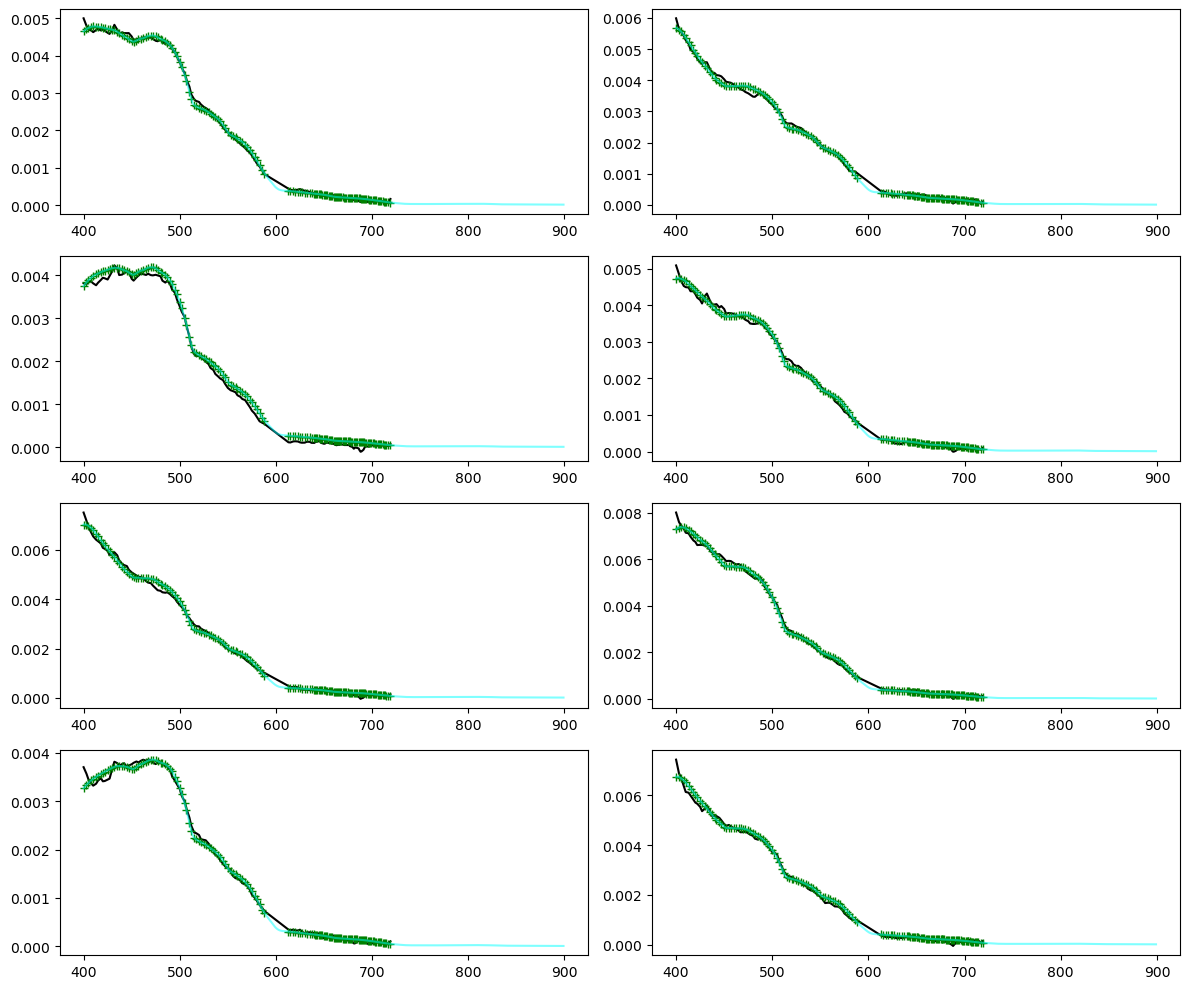

In [44]:
orig = orig.reset_index(drop=True)
inv = inv.reset_index(drop=True)

N = 8
index = np.random.choice(inv.index, N, replace=False)
Nx = 2
Ny = 4
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(12,10))
ix, iy = (0,0)
for i in index:
    ax[iy, ix].plot(wv_orig, orig[wv_orig_str].iloc[i, :].values, 'k-')
    ax[iy, ix].plot(wv, inv[wv_str].iloc[i,:].values, 'g+')
    ax[iy, ix].plot(wavelengths, sim.iloc[i,:].values, '-', color='aqua', alpha=0.5)
    ix +=1
    if ix == Nx:
        ix=0
        iy +=1

fig.tight_layout()
plt.show()

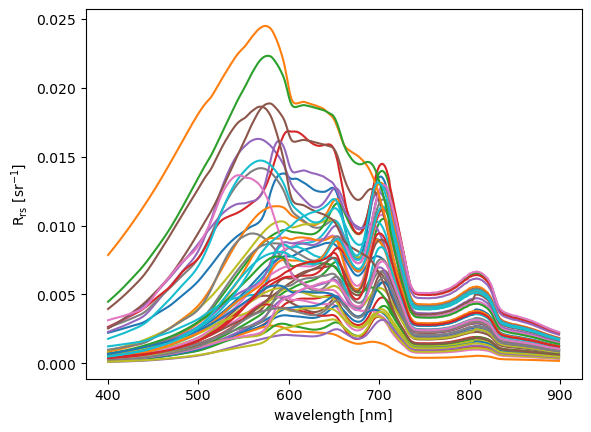

In [11]:
plt.plot(wavelengths, R_rs_sim.iloc[:50,:].T)
plt.xlabel("wavelength [nm]")
plt.ylabel("$\mathrm{{R}_{rs}\ [sr^{-1}]}$")
plt.show()

In [33]:

# R_rs_arr = R_rs_sim.iloc[:n, :].values
R_rs_arr = R_rs_sim.values
avw = np.array([owt.avw(x, wavelengths) for x in R_rs_arr])
ndi = np.array([indices.ndi(x[wavelengths==665],x[wavelengths==492]) for x in R_rs_arr])

qwip = np.array([owt.qwip(x) for x in avw])
qwip_interp = interp1d(np.sort(avw), qwip[np.argsort(avw)], kind="quadratic", fill_value='extrapolate')

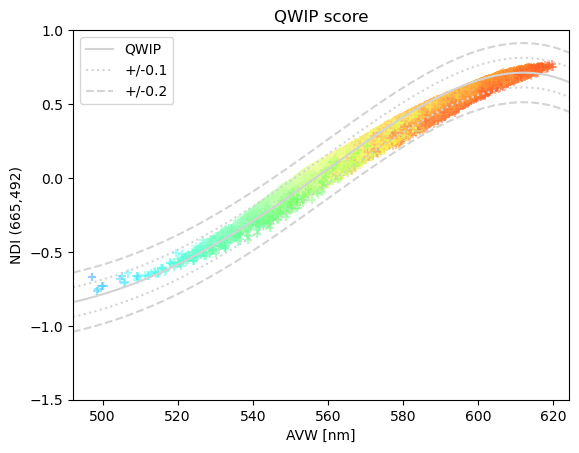

In [34]:
# Compute a pseudo true-color hex code represenation for each spectrum.
colors = np.array([plotting.spectrum_to_hex(x, wavelengths) for x in R_rs_arr])
xrange = np.arange(avw.min()-np.abs(avw.min()*0.01), avw.max()+np.abs(avw.min()*0.01), 1)

plt.scatter(avw, ndi, c=colors, marker='+', alpha=0.5)
plt.plot(xrange, qwip_interp(xrange), c="lightgrey", label="QWIP")
plt.plot(xrange, qwip_interp(xrange)+0.1,":", c="lightgrey", label="+/-0.1")
plt.plot(xrange, qwip_interp(xrange)-0.1,":", c="lightgrey")
plt.plot(xrange, qwip_interp(xrange)+0.2,"--", c="lightgrey", label="+/-0.2")
plt.plot(xrange, qwip_interp(xrange)-0.2,"--", c="lightgrey")
plt.legend()
plt.xlim(xrange.min(), xrange.max())
plt.ylim(-1.5,1)
plt.xlabel('AVW [nm]')
plt.ylabel('NDI (665,492)')
plt.title('QWIP score')
plt.show()

41


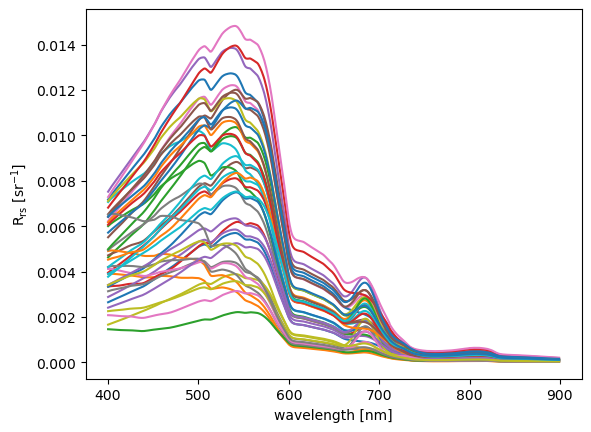

In [24]:
ID = np.array(avw < 520.)
print(np.sum(ID))

plt.plot(wavelengths, R_rs_sim.loc[ID,:].T)
plt.xlabel("wavelength [nm]")
plt.ylabel("$\mathrm{{R}_{rs}\ [sr^{-1}]}$")
plt.show()

In [25]:
param_DF.loc[ID,:]

,C_0,C_6,C_5,C_7,C_Y,C_ism,L_fl_lambda0,b_ratio_d,S_cdom
3440,0.639568,0.000000,0.000000,0.000000,0.086821,0.849858,0.000496,0.021507,0.013791
3586,0.000000,0.423328,0.000000,0.000000,0.013165,0.207592,0.004054,0.021359,0.012960
3939,0.690796,0.000000,0.000000,0.000000,0.039474,1.814231,0.025368,0.021450,0.017520
5750,2.367314,0.000000,0.000000,0.000000,0.040993,0.930918,0.018443,0.021138,0.012335
6194,0.000000,0.786486,0.000000,0.000000,0.070549,0.973311,0.006185,0.021155,0.013825
6285,1.358700,0.000000,0.000000,0.000000,0.031651,1.573081,0.012237,0.021406,0.010416
6682,0.221680,0.000000,0.000000,0.000000,0.015166,2.160286,0.033970,0.021406,0.018020
8431,0.627625,0.000000,0.000000,0.000000,0.037367,0.432844,0.000571,0.021030,0.015139
8684,0.000000,1.358430,0.000000,0.000000,0.094933,0.509769,0.000262,0.021349,0.018410
8804,0.036116,0.000000,0.000000,0.000000,0.000915,1.234209,0.011934,0.021264,0.019817


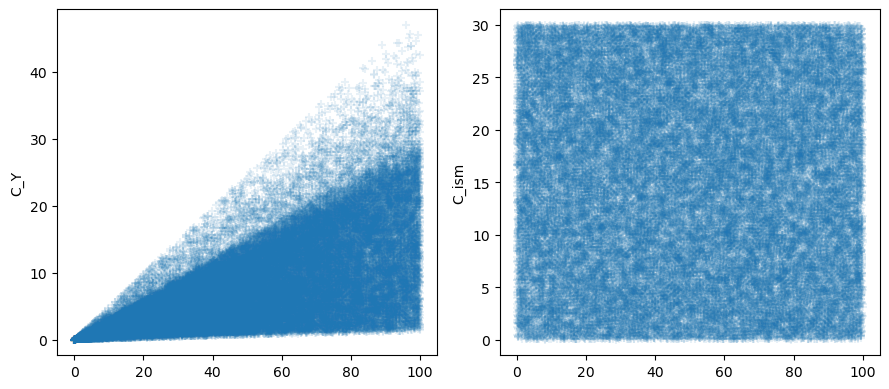

In [29]:
ChlCol = ['C_0', 'C_6', 'C_5', 'C_7']
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9,4))
ax[0].scatter(np.sum(param_DF[ChlCol].values, axis=1), param_DF['C_Y'], marker='+', alpha=0.1)
ax[1].scatter(np.sum(param_DF[ChlCol].values, axis=1), param_DF['C_ism'], marker='+', alpha=0.1)
ax[0].set_ylabel('C_Y')
ax[1].set_ylabel('C_ism')
fig.tight_layout()